In [3]:
from google.colab import files
uploaded = files.upload()

Saving Dataset for Data Analytics.xlsx to Dataset for Data Analytics.xlsx


Loading dataset from Dataset for Data Analytics.xlsx...
Original Dimensions: 4
Compressed Dimensions (95% Variance Retained): 3
Running K-Means iterations to calculate diagnostics...


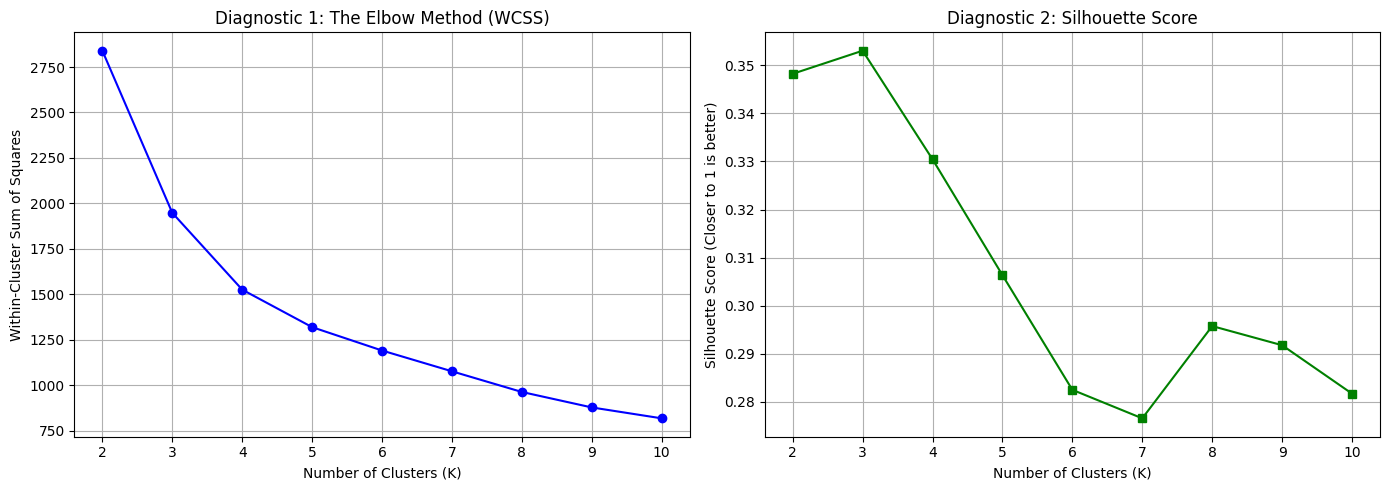


Applying final K-Means with K=4...

THE STRATEGIC PERSONA MATRIX (Human-Centric Coordinates)


,Quantity,UnitPrice,ItemsInCart,TotalPrice
Cluster 0,1.91,192.77,3.94,160.54
Cluster 1,4.28,550.04,7.02,2159.11
Cluster 2,4.04,167.50,7.24,863.73
Cluster 3,1.74,481.91,3.98,996.04


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---------------------------------------------------------
# 1. DATA INGESTION
# ---------------------------------------------------------
file_path = "Dataset for Data Analytics.xlsx"
print(f"Loading dataset from {file_path}...")

df = pd.read_excel(file_path)

# Drop non-behavioral identifiers (Update 'CustomerID' if your column is named differently)
if 'CustomerID' in df.columns:
    X_raw = df.drop(columns=['CustomerID'])
else:
    X_raw = df.copy()

# Ensure we only use numerical data for distance calculations
X_num = X_raw.select_dtypes(include=[np.number])

# ---------------------------------------------------------
# 2. THE SCALE PHASE
# ---------------------------------------------------------
# StandardScaler prevents magnitude distortion in Euclidean distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# ---------------------------------------------------------
# 3. THE COMPRESS PHASE (PCA)
# ---------------------------------------------------------
# Implementing the 95% Cumulative Variance Rule
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original Dimensions: {X_scaled.shape[1]}")
print(f"Compressed Dimensions (95% Variance Retained): {X_pca.shape[1]}")

# ---------------------------------------------------------
# 4. THE DIAGNOSTIC GATEKEEPERS (Finding Optimal K)
# ---------------------------------------------------------
wcss = []
silhouette_scores = []
k_range = range(2, 11)

print("Running K-Means iterations to calculate diagnostics...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_pca)

    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, cluster_labels))

# Plotting the Gatekeepers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gatekeeper 1: The Elbow Method
ax1.plot(k_range, wcss, marker='o', linestyle='-', color='b')
ax1.set_title('Diagnostic 1: The Elbow Method (WCSS)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Within-Cluster Sum of Squares')
ax1.grid(True)

# Gatekeeper 2: The Silhouette Score
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_title('Diagnostic 2: Silhouette Score')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score (Closer to 1 is better)')
ax2.grid(True)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. TRANSLATION: REVERSE-ENGINEERING CENTROIDS
# ---------------------------------------------------------
# NOTE: Review the charts generated above. Set optimal_k to the mathematical "elbow"
# or the peak Silhouette Score. We default to 4 here based on the Strategic Persona Matrix.
optimal_k = 4

print(f"\nApplying final K-Means with K={optimal_k}...")
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
final_clusters = final_kmeans.fit_predict(X_pca)

# The Centroids exist in abstract PCA space. We must reverse engineer them.
abstract_centroids = final_kmeans.cluster_centers_

# Step A: Inverse transform the PCA compression
scaled_centroids = pca.inverse_transform(abstract_centroids)

# Step B: Inverse transform the Standard Scaler projection
human_centric_centroids = scaler.inverse_transform(scaled_centroids)

# Create the Persona Matrix DataFrame
persona_matrix = pd.DataFrame(
    human_centric_centroids,
    columns=X_num.columns,
    index=[f"Cluster {i}" for i in range(optimal_k)]
)

print("\n========================================================")
print("THE STRATEGIC PERSONA MATRIX (Human-Centric Coordinates)")
print("========================================================")
display(persona_matrix.round(2))

# Optional: Add the assigned clusters back to your original dataframe for export
df['Assigned_Persona'] = final_clusters
# df.to_excel("Segmented_Customers.xlsx", index=False)